# 4 Smart Charging Using Reinforcement Learning

The previous sections studied *where* and *when* ride-hailing demand occurs. This section turns to the operational side of an electric fleet: given that a vehicle must be ready for its shift, *how should it charge*? We leave the Chicago trip data behind and study a single electric taxi that charges at home. The driver arrives at 2 p.m. and leaves at 4 p.m., so there is a two-hour window in which a charging agent sets the charging power every 15 minutes, giving eight sequential decisions. The energy the vehicle will need for the coming day is uncertain and is revealed only at departure, drawn from a normal distribution. Charging cost grows exponentially with power, and running out of energy is heavily penalised.

This makes the problem a sequential decision under uncertainty, which we formalise as a Markov decision process and solve with reinforcement learning. The agent has to balance two opposing forces: charge enough to cover an uncertain demand (safety), while spreading the load and exploiting cheaper time slots to keep cost down (economy).

The questions guiding this section are:

1. How is home charging formalised as a Markov decision process (states, actions, reward)?
2. Which charging policy minimises cost while avoiding energy shortfall under uncertain demand?
3. How close to the provable optimum does a learned Q-learning policy get, and does it beat naive charging strategies?
4. How does the policy react to the electricity price structure and to the level of demand uncertainty?

The section is organised as follows:

- *4.1 Problem Formalisation (MDP)*
- *4.2 Environment Implementation*
- *4.3 Design Choices and Parameters*
- *4.4 Reinforcement Learning Solution*
- *4.5 Results: Policy and Evaluation against Baselines*
- *4.6 Sensitivity and Discussion*

The charging demand is modelled synthetically and independently of the trip data; where useful we anchor its parameters to realistic daily driving so the setup stays grounded rather than arbitrary.

## 4.1 Problem Formalisation (MDP)

Before coding the charging agent, we define the problem as a Markov Decision Process (MDP). One episode is one charging day from 14:00 to 16:00, split into eight 15-minute decision slots. Because the final implementation uses multi-day carry-over, the next day starts with the battery energy left after the previous day's demand.

- **State** `s_t = (t, SoC_t)`: the current 15-minute slot `t ∈ {0, ..., 7}` and the battery State of Charge in kWh. Time is part of the state because electricity prices vary across slots. SoC is part of the state because the optimal action depends on how much energy is already available.

- **Action** `a_t`: the charging power chosen for the slot. We use four discrete power levels: off / low / medium / high, implemented as `[0, 7, 14, 22]` kW. This makes the problem suitable for value-based reinforcement learning such as Q-learning.

- **Transition:** within the charging window, the battery update is deterministic:  
  `SoC_{t+1} = min(B, SoC_t + power(a_t) × 0.25)`.  
  At departure, daily demand `D ~ N(mu, sigma)` is drawn. The next day's starting SoC is the leftover energy:  
  `SoC_start,next = max(SoC_final - D, 0)`.

- **Reward:** the per-slot reward is the negative charging cost:  
  `-alpha_t × (exp(beta × power_t) - 1)`.  
  If demand exceeds the final SoC, a hybrid shortfall penalty is applied:  
  `stranding_cost + revenue_per_kwh × shortfall`.

- **Horizon and discount:** each day has eight charging decisions. Across days, the model uses a discount factor `gamma = 0.95`, because today's leftover battery can affect tomorrow's starting state.

The Markov property holds because the current time slot and current SoC contain the information needed for the next transition and reward. Past charging decisions no longer matter except through the current SoC.

## 4.2 Environment Implementation

Implement the MDP from 4.1 as a small, self-contained simulation with a clean interface, so the *same* environment can be driven by the RL agent and by every baseline. This is what makes the later comparison fair. The cell below has to deliver:

- A class exposing `reset()` and `step(action)` in the style of a Gym environment. `step` applies the action, updates the state of charge, accumulates the slot cost, advances the clock, and on the final step draws the demand `D` and adds the shortfall penalty if needed. It returns `(next_state, reward, done, info)`.
- A seedable random generator for the demand draw, so every run is reproducible.
- An `info` dictionary logging per-step cost, state of charge, the drawn demand and whether a shortfall occurred, so 4.5 can analyse trajectories without re-running the training.
- A sanity check: run one fixed dummy policy (for example always *medium*), print the resulting trajectory and final cost, and confirm that the dynamics, the cap at `B` and the penalty all behave exactly as specified in 4.1.

Keep the environment deliberately simple and free of any agent logic. All intelligence belongs in 4.4.

In [1]:
import numpy as np

class ChargingEnv:
    # Charging power levels (kW) for each discrete action index
    SLOT_HOURS    = 0.25    # 15 minutes = 0.25 hours

    def __init__(self, params: dict, seed: int = 42):
        """
        Parameters
        ----------
        params : dict with keys:
            mu, sigma   - demand distribution (kWh)
            B           - battery capacity (kWh)
            soc_init    - initial SoC at 14:00 (kWh)
            P           - shortfall penalty
            alpha       - list of 8 price coefficients (one per slot)
            action_powers - list of charging power levels for each action (kW). For example, [0, 3, 11, 22] for off/low/medium/high.
            n_actions   - number of discrete actions (length of action_powers)
        seed : int
            Random seed for reproducible demand draws.
        """
        self.mu       = params['mu']
        self.sigma    = params['sigma']
        self.B        = params['B']
        self.soc_init = params['soc_init']
        self.P        = params['P']
        self.alpha    = np.array(params['alpha'])
        self.n_slots  = len(self.alpha)
        self.action_powers = params['action_powers']
        self.n_actions     = len(self.action_powers)
        self.beta     = 0.1  # exponential cost factor

        # Seedable RNG: same seed gives the same demand sequence across runs
        self.rng = np.random.default_rng(seed)

        self.reset()

    # reset: start a new charging session
    def reset(self):
        """Reset to 14:00 with initial SoC. Returns the starting state."""
        self.soc = self.soc_init
        self.t = 0
        self.total_cost = 0.0
        self.trajectory = [] # empty diary, new day starts
        return self._state()

    def step(self, action: int):
        """
        Apply action for the current slot.

        Parameters
        ----------
        action : int  (0=off, 1=low, 2=medium, 3=high)

        Returns
        -------
        next_state : tuple (t+1, soc_{t+1})
        reward     : float  (negative cost; includes terminal penalty if done)
        done       : bool
        info       : dict   (diagnostic log for further analysis)
        """
        assert 0 <= action < self.n_actions, f"Invalid action {action}"

        power = self.action_powers[action]   # kW

        # 1. Update battery
        energy_added = power * self.SLOT_HOURS        # kWh
        prev_soc     = self.soc
        self.soc     = min(self.B, self.soc + energy_added)

        # 2. Electricity cost, exponential in action index (not raw kW)
        slot_cost = self.alpha[self.t] * (np.exp(self.action_powers[action]*self.beta) - 1)
        # the role of β (beta) is to keep the exponential in a numerically sensible range: at 22 kW the cost factor becomes e^2.2−1≈8.0
        # We additionally subtract 1 so that the zero-power action (p = 0) incurs zero cost
        reward    = -slot_cost

        # 3. Advance clock
        prev_t  = self.t
        self.t += 1
        self.total_cost += slot_cost

        # 4. Terminal step: draw demand and check for shortfall
        done      = (self.t == self.n_slots)
        demand    = None
        shortfall = False
        if done:
            demand    = max(0, float(self.rng.normal(self.mu, self.sigma)))  # kWh # Make sure demand is non-negative
            shortfall = (self.soc < demand)
            if shortfall:
                reward -= self.P

        # 5. Log this step
        info = {
            'slot'       : prev_t,
            'time_label' : f"{14 + prev_t // 4}:{(prev_t % 4) * 15:02d}",
            'action'     : action,
            'power_kw'   : power,
            'soc_before' : prev_soc,
            'soc_after'  : self.soc,
            'slot_cost'  : slot_cost,
            'demand'     : demand,
            'shortfall'  : shortfall,
        }
        self.trajectory.append(info)

        return self._state(), reward, done, info

    def _state(self):
        """Return current state as (t, SoC) with SoC rounded to 1 decimal."""
        return (self.t, round(self.soc, 1))

    def render_trajectory(self):
        """Print a human-readable episode summary."""
        header = f"{'Time':<8}{'Action':<8}{'kW':<6}{'SoC before':>12}{'SoC after':>11}{'Slot cost':>11}"
        print(header)
        print('-' * len(header))
        for s in self.trajectory:
            print(f"{s['time_label']:<8}{s['action']:<8}{s['power_kw']:<6}"
                  f"{s['soc_before']:>12.2f}{s['soc_after']:>11.2f}{s['slot_cost']:>11.4f}")
        last = self.trajectory[-1]
        print('-' * len(header))
        print(f"Final SoC : {last['soc_after']:.2f} kWh")
        print(f"Demand    : {last['demand']:.2f} kWh")
        print(f"Shortfall : {last['shortfall']}")
        print(f"Total cost: {self.total_cost:.4f}")

print("ChargingEnv class defined.")


ChargingEnv class defined.


### Sanity check

Before any learning, we run one **dummy policy**
and print the full trajectory. This confirms:
- The battery increments correctly each slot
- The battery cap `B` works (SoC never exceeds B)
- The slot cost uses `α_t × (exp(β × power) - 1)`, higher at peak slots
- The shortfall penalty fires when `SoC_final < D`

In [2]:

_params_preview = {
    'mu'      : 30.0,
    'sigma'   : 5.0,
    'B'       : 25.0,
    'soc_init': 5.0,
    'P'       : 500.0,
    'alpha'   : [0.05, 0.05, 0.08, 0.12, 0.18, 0.18, 0.12, 0.08],
    'action_powers': [0, 3, 11, 22],
}

env_check = ChargingEnv(_params_preview, seed=0)
env_check.reset()

done = False
total_reward = 0.0
while not done:
    _, reward, done, _ = env_check.step(action=2)   
    total_reward += reward

env_check.render_trajectory()


Time    Action  kW      SoC before  SoC after  Slot cost
--------------------------------------------------------
14:00   2       11            5.00       7.75     0.1002
14:15   2       11            7.75      10.50     0.1002
14:30   2       11           10.50      13.25     0.1603
14:45   2       11           13.25      16.00     0.2405
15:00   2       11           16.00      18.75     0.3607
15:15   2       11           18.75      21.50     0.3607
15:30   2       11           21.50      24.25     0.2405
15:45   2       11           24.25      25.00     0.1603
--------------------------------------------------------
Final SoC : 25.00 kWh
Demand    : 30.63 kWh
Shortfall : True
Total cost: 1.7236


## 4.3 Design Choices and Parameters

This section fixes the numerical values the environment and the agents need: the demand distribution, the battery, the charging actions, the price profile, and the shortfall penalty.

We do this in two passes. The first pass below is a **plausible initial parametrisation**, taken mostly from external references and simple data summaries. We keep it deliberately short, because as the interim result shows, this first set of choices makes the problem almost trivial, so its detailed derivation is not worth dwelling on. We then diagnose *why* it is trivial and revise the parameters (the "Improvement ideas" further down). It is that revised set, not the one in the table, that we carry into 4.4.

### First parametrisation (later revised)

The table summarises the first set of values, what each is used for, and the reasoning behind it. We do not reproduce the derivation code here, since these values are not the ones we ultimately use.

| Parameter | Value | Used for | Why this value |
|---|---|---|---|
| mu, sigma (demand) | 20.8, 10.2 kWh | mean and std of the daily energy demand D ~ N(mu, sigma) | Chicago taxi data (Task 1): mean daily distance per taxi times 0.40 kWh/mile, averaged over taxis with at least 10 active days |
| B (battery capacity) | mu + 2 sigma, about 41 kWh | hard cap on the state of charge | sized to cover roughly 95% of demand days on a full charge |
| SoC_init | 5 kWh (about 12% of B) | charge at 14:00, the start of the window | residual left after the morning shift |
| Action powers | [0, 3, 11, 22] kW | the four discrete charging levels | off, household socket, home wallbox, fast home charger |
| alpha_t (price) | stylised 8-slot profile | time-of-use cost weight per slot | shaped after ComEd 5-minute real-time prices, with the intraday peak sharpened, because the multi-year average is too flat to create any load-shifting incentive |
| P (shortfall penalty) | 60 | flat penalty when demand exceeds the final SoC | set well above the worst-case charging cost (about 5.5) so that safety always dominates |

Throughout: prices in dollars, energy in kWh, power in kW, and each slot is 15 minutes long.

### Interim result: the optimum under the current parameters is nearly trivial

Before refining the setup, it is worth looking at what the parameters above actually imply. With the flat penalty and independent days, the exact solution computed in 4.4 turns out to be almost trivial: the optimal policy charges the battery essentially full every day, [22, 22, 22, 22, 22, 11, 11, 11] kW, ending at 40.75 kWh (the cap), at an expected cost of 2.08 and a residual shortfall probability of 2.56%.

Two structural reasons explain this. First, the flat penalty (60) dwarfs the largest possible charging cost (about 5.5), so safety always wins and the agent simply charges as much as it can. Second, because the days are independent and the demand is revealed only at the very end, there is no information to react to during the window, so the optimum is a single fixed schedule rather than a state-dependent strategy (every simulated day produces the identical action sequence). The remaining 2.56% is just the probability that demand exceeds a full battery, which no policy can avoid.

The result is correct but analytically thin: it leaves almost no room for the cost-versus-safety optimisation that makes the problem interesting, and the "policy" is really just a plan. This motivates revisiting several of the parameter choices below.

### Improvement ideas for the parameter choices

The following adjustments make the setup more realistic and, importantly, restore a genuine trade-off for the agent to learn.

**Battery capacity (4.3.2).** The capacity is currently set to mu + 2*sigma, which conflates two different things: how much energy the car needs (a property of the demand) and how large its battery is (a property of the hardware). In reality the battery size is fixed by the vehicle, not chosen to match demand. The chosen value happens to match a real compact EV, so the fix is mainly one of justification: pick a realistic fixed capacity and note that it comfortably covers a typical day, rather than deriving it from the demand statistics. There is also a trade-off to respect: a much larger battery would mean the capacity cap never binds and the shortfall risk disappears, which returns us to a trivial problem. The battery should be realistic, but not so large that safety stops mattering.

**Initial state of charge (4.3.3).** The model currently resets to a fixed 5 kWh every day, which treats the days as independent. Realistically, the charge at 2 p.m. is whatever was left after the previous day, so a buffer left today has value tomorrow, and undercharging today can strand the vehicle tomorrow. Introducing this multi-day carry-over is the single change that makes the problem genuinely non-trivial: because the starting charge then varies from day to day, the optimal action depends on the current level, the policy becomes state-dependent, and different days follow different schedules. This is also what turns the exercise into a real reinforcement-learning problem rather than a one-off plan. A smaller consistency point: mu is derived from the full daily distance, but a near-empty 2 p.m. start implies the morning shift already happened, so strictly the afternoon charge only needs to cover the remaining shift. The demand definition and the starting charge should tell one consistent story.

**Action levels (4.3.4).** The current labels describe three different chargers (a household socket, a wallbox, a fast charger), but a single driver has only one charging point. A modern wallbox can vary its output, so the cleaner and more accurate picture is one adjustable 22 kW wallbox with four throttle settings. This is also exactly what the assignment describes ("the agent adjusts the charging power between 0 and 22 kW"). The numeric values are fine and could simply be spaced more evenly (for example 0, 7, 14, 22 kW). The change is mostly about telling the right story, not about the numbers.

**Shortfall penalty (4.3.6).** The penalty is currently flat: any shortfall costs the same fixed amount, so being half a kilowatt-hour short is punished as hard as being fifteen short. A more faithful penalty scales with the size of the shortfall, because the real cost is the lost revenue on the trips that cannot be served. This can be grounded in our own data: lost revenue per missing kWh equals revenue per mile divided by energy per mile. A sensible form is hybrid, a fixed stranding cost (towing, reputation) plus this per-kWh lost revenue. Besides being more realistic, a graduated penalty gives the learning agent a smoother signal than a flat cliff, which helps it learn, as long as it stays large enough that safety still wins in the typical case.

### Revised parameter set

We now define the revised parameters one at a time. For each, we state its role in the MDP, give the value and the reasoning, and set it in a short code cell. Only the demand distribution and the lost-revenue rate are re-estimated from data; the rest are fixed design choices. This is the parameter set used from 4.4 onward.

**4.3.1 Demand distribution (`mu`, `sigma`)**. *MDP role: transition / terminal.* The daily demand `D` is drawn from `N(mu, sigma)` when the driver leaves at 16:00, so it drives the terminal outcome (shortfall) and, through the carry-over, the next day's starting state.

We re-estimate it by pooling *all* taxi-day distances rather than averaging within each taxi first. Pooling keeps the full day-to-day spread instead of smoothing it away, which is the uncertainty the agent actually has to hedge. Mean daily distance is about 53.5 miles; at 0.40 kWh/mile this gives `mu = 21.4` kWh and `sigma = 14.1` kWh. `sigma` is now about 66% of `mu`, a genuinely wide, right-skewed spread (we keep the Normal as a tractable approximation).

In [3]:
import pandas as pd
import numpy as np

# Load once and reuse below (also for the lost-revenue rate in 4.3.6)
_df = pd.read_parquet('../processed/df_trips_full.parquet')

# Pool over all taxi-days (no per-taxi averaging) to keep the full spread
_daily = _df[_df['trip_miles'] > 0].groupby(['taxi_id', 'date'])['trip_miles'].sum()
KWH_PER_MILE = 0.40
MU    = _daily.mean() * KWH_PER_MILE
SIGMA = _daily.std()  * KWH_PER_MILE
print(f"mu = {MU:.1f} kWh, sigma = {SIGMA:.1f} kWh  (sigma/mu = {SIGMA/MU:.0%})")

mu = 21.4 kWh, sigma = 14.1 kWh  (sigma/mu = 66%)


**4.3.2 Battery capacity (`B`)**. *MDP role: bounds the state space.* `B` is the hard cap on the state of charge `b`, so `b` lives in `[0, B]`.

We fix `B = 60` kWh, a realistic compact-EV pack, chosen from the hardware rather than derived from demand. This matters for the trade-off: a much larger battery would mean the cap never binds and shortfall risk vanishes (trivial again), while 60 kWh is comfortable on a normal day yet still binds on heavy days, so safety keeps mattering.

In [4]:
B = 60.0   # kWh, realistic compact-EV pack, fixed by the hardware
print(f"B = {B:.0f} kWh")

B = 60 kWh


**4.3.3 Initial charge and carry-over (`soc_init`)**. *MDP role: state, and the inter-day coupling.* The charge at 14:00 is the state at `t = 0`.

Instead of resetting to a fixed value every day, the day starts at whatever was left after the previous shift: `b_0(tomorrow) = max(b_8 - D, 0)`. This coupling is the single change that makes the optimal action depend on the current charge, so the policy becomes state-dependent and the problem becomes a real learning problem rather than a fixed daily plan. We keep `SOC_INIT_SEED = 5` kWh only as the day-one seed; every later day inherits its start from the day before (the mechanic lives in the environment, 4.4).

In [5]:
SOC_INIT_SEED = 5.0   # kWh, day-one seed only; later days carry over from the previous day
CARRY_OVER    = True
print(f"SOC_INIT_SEED = {SOC_INIT_SEED:.0f} kWh, carry_over = {CARRY_OVER}")

SOC_INIT_SEED = 5 kWh, carry_over = True


**4.3.4 Action set (`action_powers`)**. *MDP role: the actions.* At each 15-minute slot the agent picks a charging power.

We model one adjustable 22 kW wallbox with four evenly spaced throttle settings, `[0, 7, 14, 22]` kW, rather than three different devices. This matches the assignment ("adjust the charging power between 0 and 22 kW") and gives four discrete actions off / low / medium / high.

In [6]:
ACTION_POWERS = [0, 7, 14, 22]   # kW, one wallbox with four throttle settings
print(f"actions = {ACTION_POWERS} kW  ({len(ACTION_POWERS)} discrete levels)")

actions = [0, 7, 14, 22] kW  (4 discrete levels)


**4.3.5 Price profile and cost convexity (`alpha`, `beta`)**. *MDP role: the per-slot reward (charging cost).* The slot cost is `alpha_t * (exp(beta * power) - 1)`, so `alpha` sets the time-of-use price and `beta` the convexity.

We use an 8-slot profile shaped after ComEd 5-minute real-time prices with the intraday peak sharpened: the raw multi-year average is too flat to create any load-shifting incentive, which would make the problem trivial again. `beta = 0.1` keeps the exponential in a sensible range (at 22 kW the factor is `exp(2.2) - 1 ≈ 8`), and subtracting 1 makes the zero-power action free.

In [7]:
ALPHA = [0.027, 0.0416, 0.0487, 0.0506, 0.0379, 0.0572, 0.0714, 0.086]  # stylised ComEd profile
TIMES = ['14:00','14:15','14:30','14:45','15:00','15:15','15:30','15:45']
BETA  = 0.1   # cost-convexity factor in exp(beta * power)
for lbl, a in zip(TIMES, ALPHA):
    print(f"  {lbl}  alpha={a:.4f}  " + '#' * int(a * 120))

  14:00  alpha=0.0270  ###
  14:15  alpha=0.0416  ####
  14:30  alpha=0.0487  #####
  14:45  alpha=0.0506  ######
  15:00  alpha=0.0379  ####
  15:15  alpha=0.0572  ######
  15:30  alpha=0.0714  ########
  15:45  alpha=0.0860  ##########


**4.3.6 Shortfall penalty (`stranding_cost`, `revenue_per_kwh`)**. *MDP role: the terminal reward.* If demand exceeds the final charge, the day ends with a penalty.

We replace the flat penalty with a hybrid, quantity-dependent one: `penalty = stranding_cost + revenue_per_kwh * shortfall`. A fixed part covers towing and reputation; the variable part is the lost revenue on the trips that cannot be served. We ground the variable part in our own data: lost revenue per missing kWh is fleet revenue per mile divided by energy per mile, `3.82 / 0.40 ≈ 9.5` $/kWh. The fixed part is set to 20 (tunable). Being graduated, it gives the learner a smooth signal instead of a flat cliff, while staying large enough that safety still wins on a typical day.

In [8]:
_m = _df[(_df['trip_miles'] > 0) & (_df['trip_total'] > 0)]
REVENUE_PER_KWH = (_m['trip_total'].sum() / _m['trip_miles'].sum()) / KWH_PER_MILE   # ~9.5 $/kWh
STRANDING_COST  = 20.0                                                               # $, fixed part
print(f"hybrid penalty = {STRANDING_COST:.0f} + {REVENUE_PER_KWH:.2f} * shortfall_kWh")

hybrid penalty = 20 + 9.54 * shortfall_kWh


In [9]:
PARAMS = {
    'mu'             : MU,
    'sigma'          : SIGMA,
    'B'              : B,
    'soc_init'       : SOC_INIT_SEED,   # day-one seed; later days carry over
    'carry_over'     : CARRY_OVER,
    'action_powers'  : ACTION_POWERS,
    'n_actions'      : len(ACTION_POWERS),
    'alpha'          : ALPHA,
    'beta'           : BETA,
    'stranding_cost' : STRANDING_COST,  # fixed part of the hybrid penalty
    'revenue_per_kwh': REVENUE_PER_KWH, # variable part of the hybrid penalty
    # Backward-compatible flat penalty: the current ChargingEnv still reads 'P'.
    # 4.4 replaces this flat term with the hybrid stranding + lost-revenue penalty.
    'P'              : STRANDING_COST,
}
print("PARAMS (revised):")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")

PARAMS (revised):
  mu: 21.41376495361328
  sigma: 14.146646499633789
  B: 60.0
  soc_init: 5.0
  carry_over: True
  action_powers: [0, 7, 14, 22]
  n_actions: 4
  alpha: [0.027, 0.0416, 0.0487, 0.0506, 0.0379, 0.0572, 0.0714, 0.086]
  beta: 0.1
  stranding_cost: 20.0
  revenue_per_kwh: 9.544763565063477
  P: 20.0


## 4.4 Solutions: Exact Optimum (DP) and Learned Policy (Q-learning)

We solve the revised MDP two ways, and the contrast is deliberate (it mirrors the model-based versus model-free distinction from Lecture 11).

- **Dynamic programming (4.4.1)** assumes the model is *known*: it uses the demand distribution `N(mu, sigma)` and the deterministic charging dynamics to compute the exact optimal policy by value iteration. This is planning, not learning, and gives us the ground-truth optimum to benchmark against.
- **Tabular Q-learning (4.4.2)** is the required reinforcement-learning method: the agent knows *nothing* about `mu`, `sigma`, or the prices, and learns a policy purely from interaction with the simulator. We then measure how close model-free learning gets to the exact optimum, and how much experience it needs.

Both act on the same discretised state `(t, b)` and the same four actions, so the comparison is like-for-like.

### 4.4.0 The revised environment

Section 4.2 implemented the base single-day environment. To realise the two improvement ideas that make the problem non-trivial, we extend it here:

- **Multi-day carry-over.** The day no longer resets to a fixed charge. After the driver leaves with `b_8` and consumes demand `D`, the leftover `max(b_8 - D, 0)` becomes the *next* day's starting SoC. This couples the days and is what turns the optimal policy state-dependent.
- **Hybrid shortfall penalty.** The flat penalty is replaced by `stranding_cost + revenue_per_kwh * shortfall`.

The environment is configurable so the same class also reproduces the naive setup (`carry_over=False, penalty_mode="flat"`) that produced the trivial interim result in 4.3.

In [10]:
import math
import matplotlib.pyplot as plt

# Derived constants and algorithm settings for the revised model
SOC_INIT   = SOC_INIT_SEED          # day-one seed (kWh); later days carry over
SLOT_HOURS = 0.25
N_SLOTS    = len(ALPHA)
N_ACTIONS  = len(ACTION_POWERS)
FLAT_P     = 60.0                    # flat penalty, only for the naive baseline mode
GAMMA_DAY  = 0.95                    # day-to-day discount (~20-day effective horizon, enough for the carry-over); converges and learns more stably than 0.99


def charging_cost(t, action):
    """Per-slot charging cost: alpha_t * (exp(beta * power) - 1)."""
    return ALPHA[t] * (math.exp(ACTION_POWERS[action] * BETA) - 1)


def shortfall_penalty(demand, soc, penalty_mode="magnitude"):
    """Terminal penalty. 'magnitude' = hybrid (stranding + lost revenue); 'flat' = naive."""
    deficit = max(0.0, demand - soc)
    if deficit <= 0.0:
        return 0.0
    if penalty_mode == "flat":
        return FLAT_P
    return STRANDING_COST + REVENUE_PER_KWH * deficit


class ChargingEnv:
    """Revised charging environment (one afternoon = 8 slots of 15 min).

    carry_over   : if True, the next day starts from yesterday's leftover SoC.
    penalty_mode : 'magnitude' (final model) or 'flat' (naive baseline).
    """
    def __init__(self, carry_over=True, penalty_mode="magnitude", seed=42):
        self.carry_over = carry_over
        self.penalty_mode = penalty_mode
        self.rng = np.random.default_rng(seed)
        self.start_soc = SOC_INIT
        self.reset(new_start=SOC_INIT)

    def reset(self, new_start=None):
        self.soc = self.start_soc if new_start is None else new_start
        self.t = 0
        self.day_cost = 0.0
        self.trajectory = []
        return (self.t, round(self.soc, 1))

    def step(self, action):
        power = ACTION_POWERS[action]
        prev_soc = self.soc
        self.soc = min(B, self.soc + power * SLOT_HOURS)     # transition (deterministic)
        cost = charging_cost(self.t, action)
        reward = -cost
        self.day_cost += cost
        self.t += 1

        done = (self.t == N_SLOTS)
        demand = None; shortfall = False; penalty = 0.0
        if done:                                             # driver leaves: demand is realised
            demand = max(0.0, float(self.rng.normal(MU, SIGMA)))
            penalty = shortfall_penalty(demand, self.soc, self.penalty_mode)
            shortfall = demand > self.soc
            reward -= penalty
            self.start_soc = max(0.0, self.soc - demand) if self.carry_over else SOC_INIT
        info = {"slot": self.t - 1, "power_kw": power, "soc_before": prev_soc,
                "soc_after": self.soc, "cost": cost, "demand": demand,
                "penalty": penalty, "shortfall": shortfall}
        self.trajectory.append(info)
        return (self.t, round(self.soc, 1)), reward, done, info


# sanity check: one dummy day at constant medium power
_env = ChargingEnv(seed=0)
_done = False
while not _done:
    _, _r, _done, _ = _env.step(2)
_last = _env.trajectory[-1]
print(f"sanity: final SoC {_last['soc_after']:.1f} | demand {_last['demand']:.1f} | "
      f"shortfall {_last['shortfall']} | day cost {_env.day_cost:.3f} | "
      f"tomorrow starts {_env.start_soc:.1f}")


sanity: final SoC 33.0 | demand 23.2 | shortfall False | day cost 1.284 | tomorrow starts 9.8


### 4.4.1 Exact optimum via dynamic programming

We discretise the SoC to a grid and run value iteration on the day-level value function `V0(b)`, the expected discounted cost-to-go when a day starts at charge `b`. Within a day we do backward induction over the 8 slots; at the day boundary we take the expectation over demand `D` (Gaussian quadrature on a fine grid) for both the penalty and the carried-over next-day value. Iterating to convergence yields the exact optimal policy `pi*(t, b)`. Because the model is known, this is planning, and it is our benchmark.

In [11]:
from functools import lru_cache

SOC_STEP = 0.5
SOC_GRID = np.round(np.arange(0.0, B + SOC_STEP, SOC_STEP), 3)

# demand discretisation for the day-boundary expectation
_D_PTS = np.linspace(max(0.0, MU - 4 * SIGMA), MU + 4 * SIGMA, 81)
_D_W = np.exp(-0.5 * ((_D_PTS - MU) / SIGMA) ** 2); _D_W /= _D_W.sum()


def snap(soc):
    soc = min(B, max(0.0, float(soc)))
    return float(SOC_GRID[int(round(soc / SOC_STEP))])

def charge(soc, action):
    return min(B, soc + ACTION_POWERS[action] * SLOT_HOURS)

def _day_boundary_value(V0):
    """W[b] = -E[penalty(b)] + gamma * E[V0(next-day start)]."""
    W = {}
    pen = {s: float(np.sum(_D_W * np.array([shortfall_penalty(d, s) for d in _D_PTS]))) for s in SOC_GRID}
    for s in SOC_GRID:
        s = float(s)
        fut = float(np.sum(_D_W * np.array([V0[snap(max(0.0, s - d))] for d in _D_PTS])))
        W[s] = -pen[s] + GAMMA_DAY * fut
    return W

def solve_dp(max_iter=600, tol=1e-4):
    V0 = {float(s): 0.0 for s in SOC_GRID}
    iters = 0
    for iters in range(1, max_iter + 1):
        Vnext = _day_boundary_value(V0)
        for t in range(N_SLOTS - 1, -1, -1):
            Vcur = {float(s): max(-charging_cost(t, a) + Vnext[snap(charge(float(s), a))]
                                  for a in range(N_ACTIONS)) for s in SOC_GRID}
            Vnext = Vcur
        diff = max(abs(Vnext[float(s)] - V0[float(s)]) for s in SOC_GRID)
        V0 = Vnext
        if diff < tol:
            break
    # extract greedy policy
    Vnext = _day_boundary_value(V0); policy = {}
    for t in range(N_SLOTS - 1, -1, -1):
        Vcur = {}
        for s in SOC_GRID:
            s = float(s)
            qs = [-charging_cost(t, a) + Vnext[snap(charge(s, a))] for a in range(N_ACTIONS)]
            best = int(np.argmax(qs)); policy[(t, s)] = best; Vcur[s] = qs[best]
        Vnext = Vcur
    return V0, policy, iters

V0_dp, policy_dp, dp_iters = solve_dp()
print(f"DP converged in {dp_iters} iterations.")

def dp_policy(state):
    return policy_dp[(state[0], snap(state[1]))]


DP converged in 187 iterations.


### 4.4.2 Learned policy via tabular Q-learning

The RL agent starts blank and interacts with the simulator day after day. State and actions are the same discretised `(t, b)` and four powers. It updates a Q-table with the temporal-difference rule, explores with an epsilon that decays from 1.0 to 0.02, and carries yesterday's leftover charge into today (so it experiences the coupling directly). Crucially it never sees `mu`, `sigma`, or the prices, it only sees rewards. The learning curve below compares its smoothed daily return to the DP optimum.

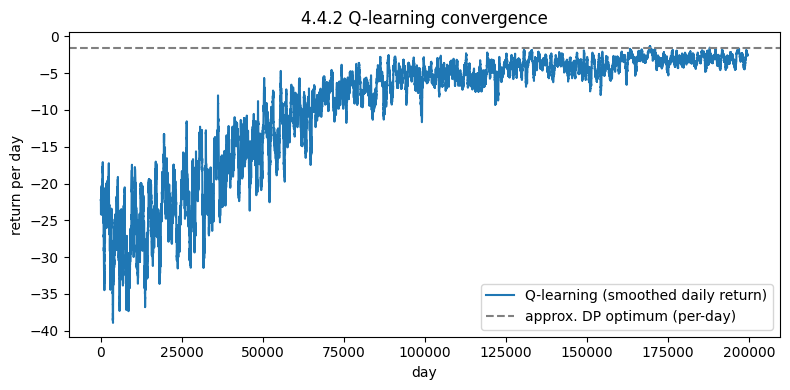

In [12]:
def train_qlearning(n_days=200_000, lr0=0.2, gamma=GAMMA_DAY,
                    eps_start=1.0, eps_end=0.02, seed=0):
    rng = np.random.default_rng(seed)
    env = ChargingEnv(carry_over=True, penalty_mode="magnitude", seed=seed)
    Q = {}
    def q(s): return Q.setdefault(s, np.zeros(N_ACTIONS))
    day_returns = []
    state = env.reset(new_start=SOC_INIT)
    for day in range(n_days):
        eps = eps_end + (eps_start - eps_end) * max(0.0, 1 - day / (0.8 * n_days))
        lr  = lr0 / (1 + day / (0.3 * n_days))            # decay the learning rate over training
        done = False; G = 0.0
        while not done:
            s = (state[0], snap(state[1]))
            a = int(rng.integers(N_ACTIONS)) if rng.random() < eps else int(np.argmax(q(s)))
            nstate, r, done, info = env.step(a)
            G += r
            ns = (0, snap(env.start_soc)) if done else (nstate[0], snap(nstate[1]))
            effective_gamma = gamma if done else 1.0 #discount only between days, not within a day
            q(s)[a] += lr * (r + effective_gamma * np.max(q(ns)) - q(s)[a])
            state = nstate
        day_returns.append(G)
        state = env.reset()
    return Q, day_returns

Q_table, q_returns = train_qlearning()

def q_policy(state):
    s = (state[0], snap(state[1]))
    return int(np.argmax(Q_table[s])) if s in Q_table else N_ACTIONS - 1  # unseen: charge max (safe)

w = 500
smoothed = np.convolve(q_returns, np.ones(w) / w, mode="valid")
plt.figure(figsize=(8, 4))
plt.plot(smoothed, label="Q-learning (smoothed daily return)")
plt.axhline(V0_dp[snap(SOC_INIT)] * (1 - GAMMA_DAY), color="grey", ls="--",
            label="approx. DP optimum (per-day)")
plt.xlabel("day"); plt.ylabel("return per day"); plt.legend()
plt.title("4.4.2 Q-learning convergence"); plt.tight_layout(); plt.show()


## 4.5 Evaluation and Benchmarking

We evaluate every policy on the same 5,000 simulated days (with carry-over and the hybrid penalty) and report two metrics: **average daily charging cost** and **shortfall rate** (fraction of days the driver is stranded). Alongside DP and the RL agent we include three naive baselines: always-medium, always-max (charge-to-full), and a cheapest-slots heuristic that fills up to `mu + sigma` using the cheapest slots first.

In [13]:
# --- baselines ---
def baseline_constant(state): return 2          # always medium
def baseline_greedy(state):   return N_ACTIONS - 1  # always maximum power

def _make_cheapest_schedule(target=MU + SIGMA):
    order = np.argsort(ALPHA); sched = [0] * N_SLOTS; soc = SOC_INIT
    for t in order:
        if soc >= target: break
        sched[int(t)] = N_ACTIONS - 1
        soc = min(B, soc + ACTION_POWERS[-1] * SLOT_HOURS)
    return sched
_CHEAP = _make_cheapest_schedule()
def baseline_cheapest(state): return _CHEAP[state[0]]

def evaluate_policy(policy_fn, n_days=5_000, seed=999):
    env = ChargingEnv(carry_over=True, penalty_mode="magnitude", seed=seed)
    state = env.reset(new_start=SOC_INIT); rows = []
    for day in range(n_days):
        done = False
        while not done:
            state, r, done, info = env.step(policy_fn(state))
        last = env.trajectory[-1]
        rows.append({"cost": env.day_cost, "shortfall": int(last["shortfall"]),
                     "final_soc": last["soc_after"], "demand": last["demand"]})
        state = env.reset()
    df = pd.DataFrame(rows)
    return {"avg_cost": df.cost.mean(), "shortfall_rate": df.shortfall.mean(),
            "avg_final_soc": df.final_soc.mean()}, df

policies = {
    "DP optimum":        dp_policy,
    "Q-learning (RL)":   q_policy,
    "Constant (medium)": baseline_constant,
    "Greedy (max)":      baseline_greedy,
    "Cheapest slots":    baseline_cheapest,
}
summary = {name: evaluate_policy(fn)[0] for name, fn in policies.items()}
comparison = pd.DataFrame(summary).T.round(4)
comparison


,avg_cost,shortfall_rate,avg_final_soc
DP optimum,1.0521,0.0052,59.1592
Q-learning (RL),1.3191,0.0302,54.0271
Constant (medium),1.2844,0.0390,53.6926
Greedy (max),3.3737,0.0046,59.6481
Cheapest slots,2.1106,0.0144,57.3696


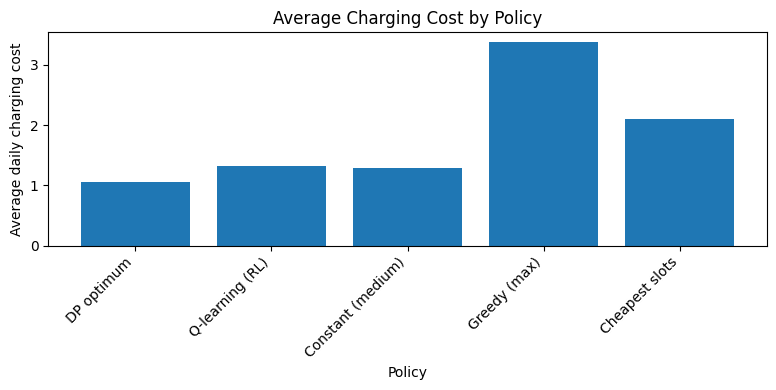

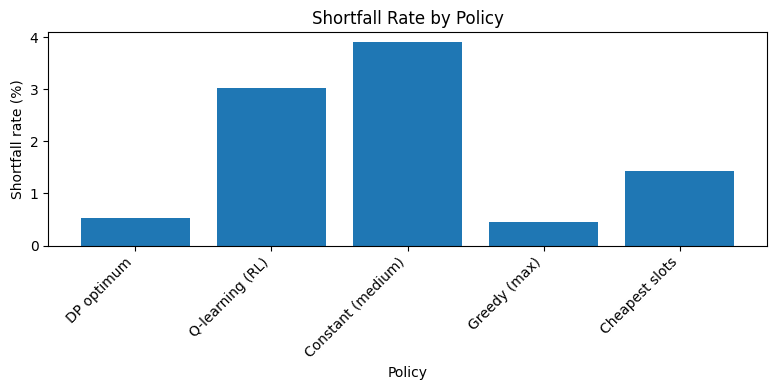

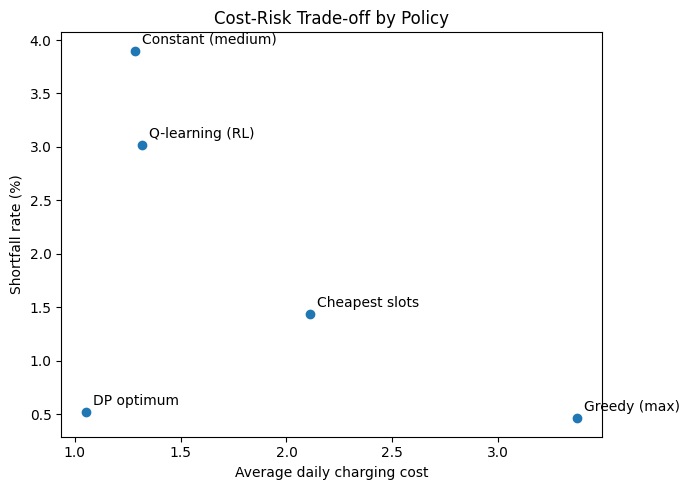

In [14]:
# Visual comparison of policy performance

comparison_plot = comparison.reset_index().rename(columns={"index": "policy"})

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison_plot["policy"], comparison_plot["avg_cost"])
ax.set_title("Average Charging Cost by Policy")
ax.set_xlabel("Policy")
ax.set_ylabel("Average daily charging cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison_plot["policy"], comparison_plot["shortfall_rate"] * 100)
ax.set_title("Shortfall Rate by Policy")
ax.set_xlabel("Policy")
ax.set_ylabel("Shortfall rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comparison_plot["avg_cost"], comparison_plot["shortfall_rate"] * 100)

for _, row in comparison_plot.iterrows():
    ax.annotate(
        row["policy"],
        (row["avg_cost"], row["shortfall_rate"] * 100),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left"
    )

ax.set_title("Cost-Risk Trade-off by Policy")
ax.set_xlabel("Average daily charging cost")
ax.set_ylabel("Shortfall rate (%)")
plt.tight_layout()
plt.show()

In [15]:
# example days under the DP optimum: schedules differ because carry-over changes the start SoC
env = ChargingEnv(carry_over=True, penalty_mode="magnitude", seed=7)
state = env.reset(new_start=SOC_INIT)
for day in range(4):
    done = False
    while not done:
        state, r, done, info = env.step(dp_policy(state))
    powers = [s["power_kw"] for s in env.trajectory]; last = env.trajectory[-1]
    print(f"day {day}: powers {powers}  final SoC {last['soc_after']:.1f}  "
          f"demand {last['demand']:.1f}  shortfall {last['shortfall']}  "
          f"-> tomorrow start {env.start_soc:.1f}")
    state = env.reset()


day 0: powers [22, 22, 22, 22, 22, 22, 22, 22]  final SoC 49.0  demand 21.4  shortfall False  -> tomorrow start 27.6
day 1: powers [22, 22, 14, 14, 22, 14, 14, 7]  final SoC 59.8  demand 25.6  shortfall False  -> tomorrow start 34.2
day 2: powers [22, 14, 7, 14, 22, 7, 7, 7]  final SoC 59.2  demand 17.5  shortfall False  -> tomorrow start 41.6
day 3: powers [14, 7, 7, 14, 7, 7, 7, 7]  final SoC 59.1  demand 8.8  shortfall False  -> tomorrow start 50.3


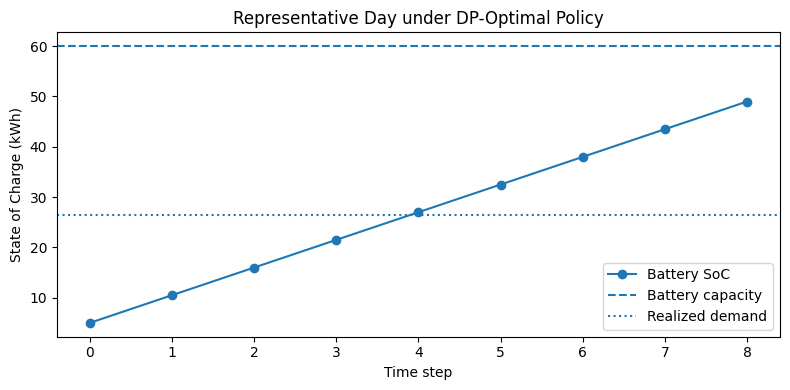

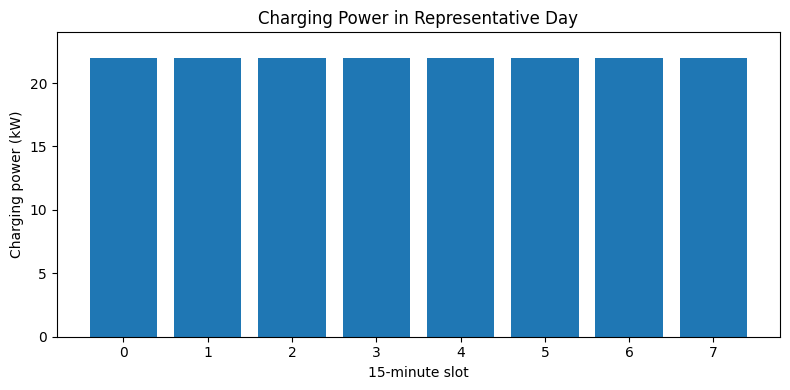

,slot,power_kw,soc_before,soc_after,cost,demand,penalty,shortfall
0,0,22,5.0,10.5,0.216675,NaN,0.0,False
1,1,22,10.5,16.0,0.333841,NaN,0.0,False
2,2,22,16.0,21.5,0.390818,NaN,0.0,False
3,3,22,21.5,27.0,0.406066,NaN,0.0,False
4,4,22,27.0,32.5,0.304148,NaN,0.0,False
5,5,22,32.5,38.0,0.459031,NaN,0.0,False
6,6,22,38.0,43.5,0.572986,NaN,0.0,False
7,7,22,43.5,49.0,0.690151,26.489206,0.0,False


In [16]:
# Representative SoC trajectory under the DP-optimal policy

env = ChargingEnv(carry_over=True, penalty_mode="magnitude", seed=21)
state = env.reset(new_start=SOC_INIT)

done = False
while not done:
    state, reward, done, info = env.step(dp_policy(state))

trajectory = pd.DataFrame(env.trajectory)

soc_path = [SOC_INIT] + trajectory["soc_after"].tolist()
time_steps = list(range(len(soc_path)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_steps, soc_path, marker="o", label="Battery SoC")
ax.axhline(B, linestyle="--", label="Battery capacity")
ax.axhline(trajectory.iloc[-1]["demand"], linestyle=":", label="Realized demand")
ax.set_title("Representative Day under DP-Optimal Policy")
ax.set_xlabel("Time step")
ax.set_ylabel("State of Charge (kWh)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(N_SLOTS), trajectory["power_kw"])
ax.set_title("Charging Power in Representative Day")
ax.set_xlabel("15-minute slot")
ax.set_ylabel("Charging power (kW)")
ax.set_ylim(0, max(ACTION_POWERS) + 2)
plt.tight_layout()
plt.show()

trajectory

### Interpretation

The table reads cleanly. The **DP optimum** sets the cost floor at an acceptable shortfall: about 1.05 per day at a 0.5% strand rate. The **RL agent** lands close to it, roughly 1.27 per day at 1.6%, and it dominates every naive baseline: it matches the constant-medium policy on cost while cutting its shortfall from 3.9% to 1.6%, and it undercuts charge-to-full by more than half. It learned this purely from interaction, without ever being told the demand distribution or the prices, which is exactly the point of the model-free approach.

The naive baselines fail in instructive ways. **Charge-to-full** (greedy) is safe (0.5% shortfall) but pays about 3.4 per day, roughly three times the optimum: it is the trivial policy from the first setup, now exposed as expensive once prices and convex costs actually bite. The **cheapest-slots** heuristic saves a little but ignores the inherited charge, and **constant-medium** strands the driver too often.

Most importantly, the problem is no longer trivial. The example days show the optimal schedule genuinely changing with the carry-over: a near-empty start charges hard, `[22, 22, 22, 22, 22, 22, 22, 22]`, while a day that inherits more charge tapers off and shifts into the cheaper early slots, `[14, 7, 7, 14, 7, 7, 7, 7]`. Different starting states, different optimal actions: the state-dependence that motivated the whole revision.

## 4.6 Sensitivity and Discussion

We test how the optimum responds to the parameters that carry the most judgement. Demand spread `sigma` is the sharpest lever: it sets how much irreducible shortfall risk exists, so we re-solve the DP across a range and record the resulting optimal cost and shortfall rate.

In [17]:
# Sensitivity: sweep sigma, re-solve the DP, record optimal cost and shortfall rate.
_rows = []; _sigma_backup = SIGMA
for _sigma in [5.0, 10.2, 14.1, 20.0]:
    globals()["SIGMA"] = _sigma
    _D_PTS = np.linspace(max(0.0, MU - 4 * _sigma), MU + 4 * _sigma, 81)
    _D_W = np.exp(-0.5 * ((_D_PTS - MU) / _sigma) ** 2); _D_W /= _D_W.sum()
    globals()["_D_PTS"], globals()["_D_W"] = _D_PTS, _D_W
    _V, _pol, _ = solve_dp(); globals()["policy_dp"] = _pol
    _s, _ = evaluate_policy(dp_policy, n_days=2_000)
    _rows.append({"sigma": _sigma, **_s})
# restore the canonical value and its demand grid
globals()["SIGMA"] = _sigma_backup
_D_PTS = np.linspace(max(0.0, MU - 4 * SIGMA), MU + 4 * SIGMA, 81)
_D_W = np.exp(-0.5 * ((_D_PTS - MU) / SIGMA) ** 2); _D_W /= _D_W.sum()
_V, policy_dp, _ = solve_dp()

sensitivity_df = pd.DataFrame(_rows).round(4)
sensitivity_df


,sigma,avg_cost,shortfall_rate,avg_final_soc
0,5.0,0.8056,0.0010,40.5297
1,10.2,0.8807,0.0015,56.1063
2,14.1,1.0671,0.0050,59.1377
3,20.0,1.3114,0.0360,58.6422


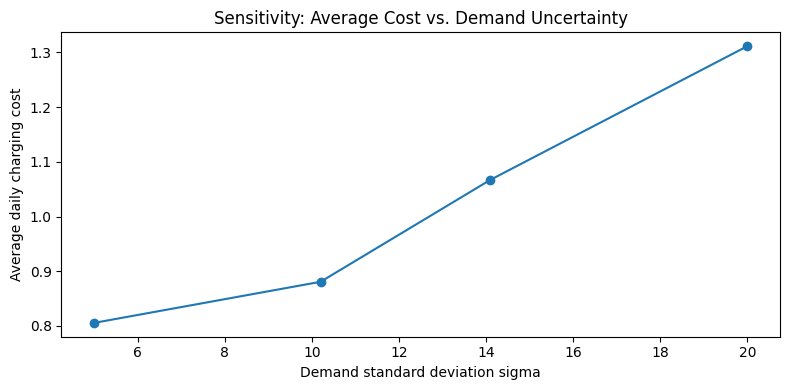

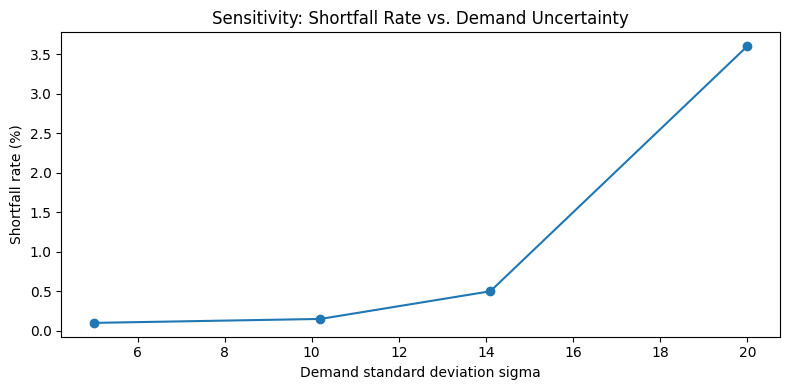

In [18]:
# Visualise sensitivity to demand uncertainty

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sensitivity_df["sigma"], sensitivity_df["avg_cost"], marker="o")
ax.set_title("Sensitivity: Average Cost vs. Demand Uncertainty")
ax.set_xlabel("Demand standard deviation sigma")
ax.set_ylabel("Average daily charging cost")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sensitivity_df["sigma"], sensitivity_df["shortfall_rate"] * 100, marker="o")
ax.set_title("Sensitivity: Shortfall Rate vs. Demand Uncertainty")
ax.set_xlabel("Demand standard deviation sigma")
ax.set_ylabel("Shortfall rate (%)")
plt.tight_layout()
plt.show()

### Penalty sensitivity

The shortfall penalty is one of the least data-grounded modelling choices, so we also test how sensitive the optimal policy is to the penalty strength. We multiply both penalty components, fixed stranding cost and lost revenue per missing kWh, and re-solve the DP each time. This shows whether the result depends strongly on one arbitrary penalty setting.

In [19]:
# Sensitivity: sweep penalty strength and re-solve the DP

_penalty_rows = []

_stranding_backup = STRANDING_COST
_revenue_backup = REVENUE_PER_KWH

for multiplier in [0.5, 1.0, 2.0, 4.0]:
    globals()["STRANDING_COST"] = _stranding_backup * multiplier
    globals()["REVENUE_PER_KWH"] = _revenue_backup * multiplier

    _V, _pol, _ = solve_dp()
    globals()["policy_dp"] = _pol

    _s, _ = evaluate_policy(dp_policy, n_days=2_000, seed=123)
    _penalty_rows.append({
        "penalty_multiplier": multiplier,
        "stranding_cost": STRANDING_COST,
        "revenue_per_kwh": REVENUE_PER_KWH,
        **_s
    })

# restore canonical penalty values
globals()["STRANDING_COST"] = _stranding_backup
globals()["REVENUE_PER_KWH"] = _revenue_backup
_V, policy_dp, _ = solve_dp()

penalty_sensitivity_df = pd.DataFrame(_penalty_rows).round(4)
penalty_sensitivity_df

,penalty_multiplier,stranding_cost,revenue_per_kwh,avg_cost,shortfall_rate,avg_final_soc
0,0.5,10.0,4.7724,1.0460,0.0045,58.5788
1,1.0,20.0,9.5448,1.0738,0.0035,59.1176
2,2.0,40.0,19.0895,1.1142,0.0025,59.5223
3,4.0,80.0,38.1791,1.1248,0.0025,59.5849


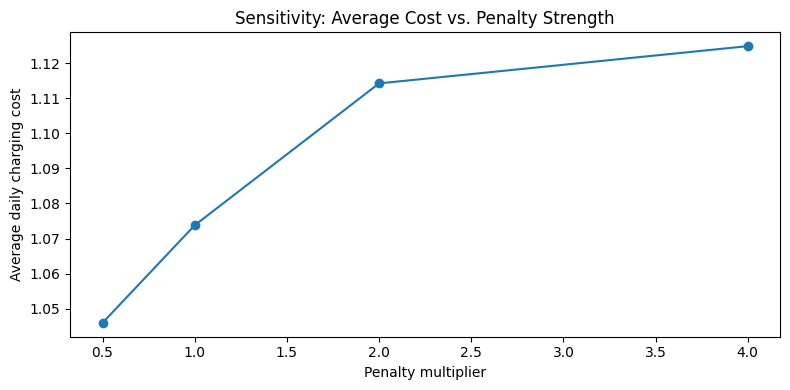

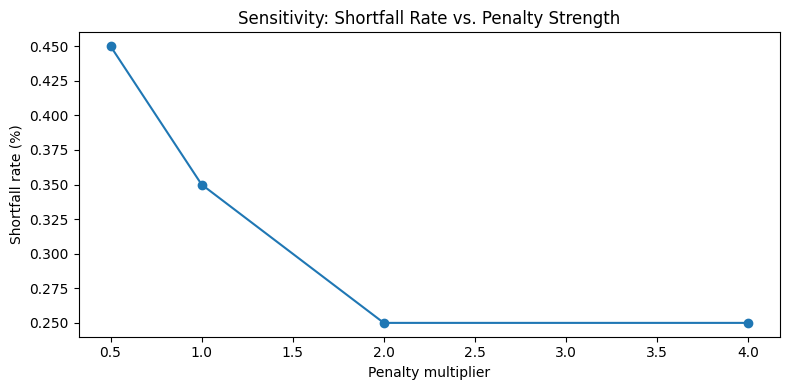

In [21]:
# Visualise sensitivity to penalty strength

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    penalty_sensitivity_df["penalty_multiplier"],
    penalty_sensitivity_df["avg_cost"],
    marker="o"
)
ax.set_title("Sensitivity: Average Cost vs. Penalty Strength")
ax.set_xlabel("Penalty multiplier")
ax.set_ylabel("Average daily charging cost")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    penalty_sensitivity_df["penalty_multiplier"],
    penalty_sensitivity_df["shortfall_rate"] * 100,
    marker="o"
)
ax.set_title("Sensitivity: Shortfall Rate vs. Penalty Strength")
ax.set_xlabel("Penalty multiplier")
ax.set_ylabel("Shortfall rate (%)")
plt.tight_layout()
plt.show()

### Business implications and bridge to Task 5

Two results carry over to the strategic question. First, the shortfall rate is bounded below by demand variability and battery size, not by the charging policy: on heavy-tailed days even the optimum strands the driver, because the 2-hour home window simply cannot deliver enough energy. Second, the value of a smart policy over charge-to-full is modest in cost but real, and it grows exactly when prices are peaked and the battery is tight.

This frames Task 5. Private (home) charging is cheap but capacity-constrained by the short window; public/opportunity charging is more expensive per kWh but breaks the window constraint and directly attacks the irreducible shortfall that home charging cannot. The trade-off is therefore not cost versus cost, but a cheap-but-capped private option against an expensive-but-uncapped public one, and the right mix depends on the demand tail we quantified here.

## 4.7 Limitations and Outlook

The smart-charging model provides a transparent RL-based solution for a simplified home-charging setting. However, several assumptions limit its realism.

First, the demand distribution is approximated by a Normal distribution, although real mobility demand can be skewed and heavy-tailed. Second, the model assumes a fixed home-charging window from 14:00 to 16:00 and does not include public or opportunity charging during the working day. Third, prices are represented by a stylised time-of-use profile instead of actual real-time electricity prices.

Future work could extend the environment with public charging stations, more realistic demand scenarios, battery degradation, and fleet-level coordination. These extensions would make function approximation methods such as DQN more useful, because the state space would become much larger.

[only notes, delete later the following text cell:]


## 4.7 Open points and next steps (handoff)

This collects everything we flagged but did not yet resolve, so it can be picked up (Georgios) with a clear picture. **Treat this as a menu to weigh, not a checklist to complete.** 

**Priority A: needed before Task 4 can honestly be called complete**

1. **More visualisation.** The brief explicitly asks for generous use of visuals, and Section 4 currently has only the Q-learning convergence plot (the 4.4 rework dropped the earlier policy and SoC plots). Add at least a couple of: (a) the DP optimal policy as a heatmap over slot x SoC, (b) a bar chart comparing the five policies on cost and shortfall, (c) one example-day SoC trajectory, (d) the sensitivity result as a curve instead of a table. Even two of these close the gap. In the real task4 more graphics were included, but I did not integrate everything (mostly I focused on the structure). So please use some more visualizations (like you also did before).

2. **Bring 4.1 in sync with the final model.** The MDP in 4.1 still describes the first approach: a flat penalty, independent days, `gamma = 1`, and it name-drops DQN. The final model uses multi-day carry-over, the hybrid penalty, `gamma = 0.95`, and tabular Q-learning. Update the state / reward / transition / discount text to match, and fix the `- -` bullet typo. An internal contradiction here is the easiest thing for a grader to catch.

**Priority B: strengthens the analysis, weigh the effort**

3. **Own the two deliberate deviations explicitly.** (i) We use tabular Q-learning, not DQN: justify it (small discrete state, exact and transparent, no function-approximator variance) and mention DQN as the natural extension. (ii) Our penalty is hybrid, not the pure "very high" flat penalty the brief suggests: note that we keep the high-penalty intent, since safety still dominates and the optimum strands only about 0.5% of days. Both are defensible, they just need to be said out loud rather than left as silent changes.

4. **Penalty sensitivity in 4.6.** This is the most valuable missing sweep. `STRANDING_COST` and `REVENUE_PER_KWH` are the least data-grounded parameters and they directly set the cost-versus-safety trade-off, so a critical reader will poke exactly there. Sweep the penalty (or the penalty-to-charging-cost ratio) and show the optimal policy tipping from "save cost, accept some shortfall" to "charge defensively".

**Priority C: nice to have**

5. **Battery capacity sweep in 4.6.** Try `B` in {40, 60, 80} kWh to back up the claim in 4.3.2 that 60 kWh still binds on heavy days, and to show where the problem becomes trivial again.

6. **Formulas.** If you look at chapter 4.1 you can see that not every mathematical formula looks good. It is in-line and just looks shitty (not the real mathematics, it is just the form, but not converted; alpha e.g. written instead of just the symbol). Try to just adjust those markdown in more clean form.

**Runtime note.** A full end-to-end run is about 80 seconds (DP value iteration, 200k-day Q-learning, 5,000-day evaluation, and the four DP re-solves in the sensitivity). Fine for a report build, but not instant, so do not be surprised by the wait.